# 02 — Autograd: Automatic Differentiation

**Project:** AutoGrader  
**Purpose:** Understand how PyTorch computes gradients automatically — the engine behind all neural network training  
**Covers:** requires_grad, backward(), gradient flow, computational graph, common gotchas

---

## What is Autograd?

When you train a neural network, you need to know: *"if I tweak this weight slightly, how does the loss change?"*  
That's a gradient. Computing it by hand for millions of weights is impossible.

Autograd does it automatically. Every time you do math on a tensor with `requires_grad=True`, PyTorch silently builds a **computational graph** — a record of every operation. When you call `.backward()`, it walks that graph backwards and computes every gradient for you.

Think of it like this: PyTorch watches every calculation you make, takes notes, and when you say "go" — it runs the chain rule across all those notes automatically.

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.5.1


---
## Section 1 — requires_grad: Turning on gradient tracking

In [3]:
# Without requires_grad — just a normal tensor, no tracking
a = torch.tensor([3.0])
print("requires_grad:", a.requires_grad)  # False — PyTorch ignores this tensor

# With requires_grad — PyTorch watches every operation on this tensor
b = torch.tensor([3.0], requires_grad=True)
print("requires_grad:", b.requires_grad)  # True

# Or turn it on after creation
c = torch.tensor([3.0])
c.requires_grad_(True)   # in-place, note the trailing underscore
print("requires_grad (turned on after):", c.requires_grad)

requires_grad: False
requires_grad: True
requires_grad (turned on after): True


In [4]:
# When you do math on a requires_grad tensor, the result carries a grad_fn
# grad_fn = the function that created this tensor (used to walk the graph backwards)

x = torch.tensor([2.0], requires_grad=True)

y = x ** 2          # y = x²
z = y + 3           # z = x² + 3

print("x:", x, "| grad_fn:", x.grad_fn)   # None — x is a leaf
print("y:", y, "| grad_fn:", y.grad_fn)   # PowBackward — came from x**2
print("z:", z, "| grad_fn:", z.grad_fn)   # AddBackward — came from y+3

# This chain of grad_fns IS the computational graph

x: tensor([2.], requires_grad=True) | grad_fn: None
y: tensor([4.], grad_fn=<PowBackward0>) | grad_fn: <PowBackward0 object at 0x12d41ed70>
z: tensor([7.], grad_fn=<AddBackward0>) | grad_fn: <AddBackward0 object at 0x12d41ed70>


---
## Section 2 — backward(): Computing gradients

In [5]:
# Simple example: y = x², what is dy/dx at x=3?
# Math answer: dy/dx = 2x = 2*3 = 6

x = torch.tensor([3.0], requires_grad=True)
y = x ** 2

# Call backward() — this triggers gradient computation
y.backward()

# Now x.grad holds dy/dx
print("x.grad (dy/dx at x=3):", x.grad)   # tensor([6.]) ← matches 2*3=6 ✓

x.grad (dy/dx at x=3): tensor([6.])


In [6]:
# More complex: z = 3x² + 2x + 1, what is dz/dx at x=4?
# Math answer: dz/dx = 6x + 2 = 6*4 + 2 = 26

x = torch.tensor([4.0], requires_grad=True)
z = 3 * x**2 + 2 * x + 1

z.backward()
print("dz/dx at x=4:", x.grad)   # tensor([26.]) ✓

# PyTorch computed this automatically using the chain rule — no manual math needed

dz/dx at x=4: tensor([26.])


In [7]:
# GOTCHA 1: Gradients ACCUMULATE — they don't reset automatically
# This catches everyone the first time

x = torch.tensor([2.0], requires_grad=True)

# First backward
y = x ** 2
y.backward()
print("After 1st backward:", x.grad)   # tensor([4.])  → 2*2=4 ✓

# Second backward WITHOUT zeroing grad
y = x ** 2
y.backward()
print("After 2nd backward (accumulated!):", x.grad)  # tensor([8.]) ← WRONG! 4+4=8

# Fix: zero the gradient before each backward pass
x.grad.zero_()
y = x ** 2
y.backward()
print("After zeroing + 3rd backward:", x.grad)   # tensor([4.]) ✓

# In training loops: optimizer.zero_grad() does this for all parameters

After 1st backward: tensor([4.])
After 2nd backward (accumulated!): tensor([8.])
After zeroing + 3rd backward: tensor([4.])


In [ ]:
# GOTCHA 2: backward() can only be called on a SCALAR (single number)
# Neural net loss is always a scalar, so this is fine in practice

x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

# This works — sum reduces to scalar
loss = (x ** 2).sum()   # scalar
loss.backward()
print("x.grad:", x.grad)   # [2., 4., 6.] — gradient of each element

# This would ERROR — y is a vector, not scalar:
# y = x ** 2
# y.backward()  ← RuntimeError!

---
## Section 3 — torch.no_grad(): Turning off tracking

During inference (making predictions), you don't need gradients.  
Turning them off saves memory and speeds things up.

In [8]:
x = torch.tensor([3.0], requires_grad=True)

# Normal operation — graph is built
y = x ** 2
print("With grad tracking - grad_fn:", y.grad_fn)   # PowBackward

# Inside no_grad() — no graph is built, faster and less memory
with torch.no_grad():
    y = x ** 2
    print("Inside no_grad - grad_fn:", y.grad_fn)    # None
    print("requires_grad:", y.requires_grad)          # False

# In AutoGrader: when computing similarity scores for student answers,
# you're doing inference — always wrap in torch.no_grad()

With grad tracking - grad_fn: <PowBackward0 object at 0x12d41e980>
Inside no_grad - grad_fn: None
requires_grad: False


In [9]:
# .detach() — another way to stop gradient tracking
# Creates a new tensor that shares data but has no gradient history

x = torch.tensor([2.0], requires_grad=True)
y = x ** 3

y_detached = y.detach()
print("y.requires_grad:", y.requires_grad)             # True
print("y_detached.requires_grad:", y_detached.requires_grad)  # False
print("Same value:", y_detached)                       # tensor([8.])

# Common use: converting a tensor to NumPy for plotting
# y.numpy() would error because it has requires_grad=True
# y.detach().numpy() works fine
print("As NumPy:", y_detached.numpy())

y.requires_grad: True
y_detached.requires_grad: False
Same value: tensor([8.])
As NumPy: [8.]


---
## Section 4 — The Computational Graph visualised

Let's see what the graph actually looks like for a simple expression.

In [10]:
# Let's trace through a simple neural net forward pass manually
# to see exactly what the graph looks like

# Inputs
x = torch.tensor([1.0, 2.0], requires_grad=True)   # input features
w = torch.tensor([0.5, 0.3], requires_grad=True)   # weights
b = torch.tensor([0.1],      requires_grad=True)   # bias

# Forward pass (one neuron: output = dot(x,w) + b)
weighted_sum = torch.dot(x, w)   # 1.0*0.5 + 2.0*0.3 = 1.1
output = weighted_sum + b         # 1.1 + 0.1 = 1.2

# Fake target and loss
target = torch.tensor([1.0])
loss = (output - target) ** 2    # MSE loss

print("Forward pass:")
print(f"  weighted_sum = {weighted_sum.item():.2f}")
print(f"  output       = {output.item():.2f}")
print(f"  loss         = {loss.item():.4f}")

# Backward pass — compute all gradients
loss.backward()

print("\nGradients (how much each parameter contributed to loss):")
print(f"  dL/dx = {x.grad}")   # gradient w.r.t. input
print(f"  dL/dw = {w.grad}")   # gradient w.r.t. weights ← used to update weights
print(f"  dL/db = {b.grad}")   # gradient w.r.t. bias

Forward pass:
  weighted_sum = 1.10
  output       = 1.20
  loss         = 0.0400

Gradients (how much each parameter contributed to loss):
  dL/dx = tensor([0.2000, 0.1200])
  dL/dw = tensor([0.4000, 0.8000])
  dL/db = tensor([0.4000])


In [11]:
# --- Manual gradient descent step ---
# This is what an optimizer does under the hood

learning_rate = 0.1

print("Before update:")
print(f"  w = {w.data}")
print(f"  b = {b.data}")

# Update: new_weight = old_weight - learning_rate * gradient
# Use torch.no_grad() so this update itself isn't tracked
with torch.no_grad():
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

print("\nAfter one gradient descent step:")
print(f"  w = {w.data}")
print(f"  b = {b.data}")
print("\nThis is exactly what optimizer.step() does — just for millions of weights")

Before update:
  w = tensor([0.5000, 0.3000])
  b = tensor([0.1000])

After one gradient descent step:
  w = tensor([0.4600, 0.2200])
  b = tensor([0.0600])

This is exactly what optimizer.step() does — just for millions of weights


---
## Section 5 — Autograd in context: why AutoGrader cares

In [12]:
# AutoGrader currently uses RAG + cosine similarity for grading
# If you add a learned scoring layer on top, autograd becomes essential

# Simulate: a tiny learnable scoring model
# Input: similarity score between student answer and correct answer
# Output: final grade (0 to 1)

torch.manual_seed(42)

# Learnable parameters
weight = torch.randn(1, requires_grad=True)
bias   = torch.randn(1, requires_grad=True)

# Training data: (similarity_score, true_grade)
similarity_scores = torch.tensor([0.9, 0.6, 0.3, 0.8, 0.4])
true_grades       = torch.tensor([1.0, 0.6, 0.2, 0.9, 0.3])

learning_rate = 0.1
losses = []

print("Training a simple scoring model...\n")
for epoch in range(20):
    # Forward pass
    predicted_grades = torch.sigmoid(weight * similarity_scores + bias)
    loss = ((predicted_grades - true_grades) ** 2).mean()  # MSE

    # Backward pass
    loss.backward()

    # Update weights
    with torch.no_grad():
        weight -= learning_rate * weight.grad
        bias   -= learning_rate * bias.grad

    # Zero gradients
    weight.grad.zero_()
    bias.grad.zero_()

    losses.append(loss.item())
    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | Loss: {loss.item():.4f}")

print(f"\nFinal loss: {losses[-1]:.4f} (lower = better)")

Training a simple scoring model...

Epoch  0 | Loss: 0.0889
Epoch  5 | Loss: 0.0882
Epoch 10 | Loss: 0.0876
Epoch 15 | Loss: 0.0870

Final loss: 0.0865 (lower = better)


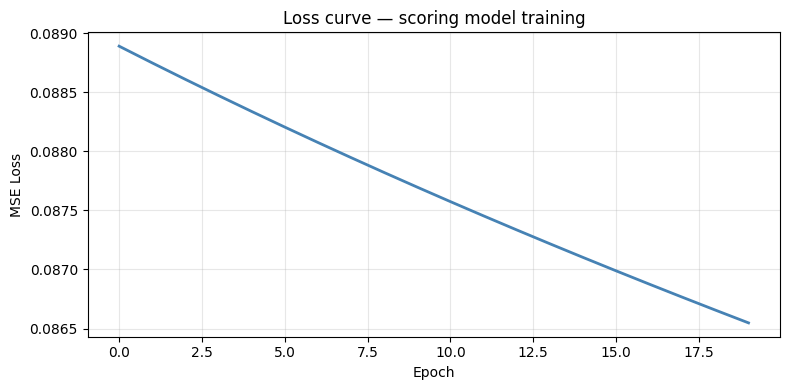

Loss is decreasing — autograd + gradient descent is working


In [13]:
# Plot the loss curve — shows the model is learning
plt.figure(figsize=(8, 4))
plt.plot(losses, color='steelblue', linewidth=2)
plt.title('Loss curve — scoring model training')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=100)
plt.show()
print("Loss is decreasing — autograd + gradient descent is working")

---
## Section 6 — Common Gotchas Summary

In [14]:
print("GOTCHA 1: Gradients accumulate — always zero before backward")
print("  Fix: optimizer.zero_grad() or x.grad.zero_()")
print()
print("GOTCHA 2: backward() needs a scalar — use .sum() or .mean() on loss")
print()
print("GOTCHA 3: Can't convert requires_grad tensor to NumPy directly")
print("  Fix: tensor.detach().numpy()")
print()
print("GOTCHA 4: Weight updates must be inside torch.no_grad()")
print("  Otherwise PyTorch tracks the update itself as part of the graph")
print()
print("GOTCHA 5: During inference, always use torch.no_grad()")
print("  Saves memory, speeds up predictions")

GOTCHA 1: Gradients accumulate — always zero before backward
  Fix: optimizer.zero_grad() or x.grad.zero_()

GOTCHA 2: backward() needs a scalar — use .sum() or .mean() on loss

GOTCHA 3: Can't convert requires_grad tensor to NumPy directly
  Fix: tensor.detach().numpy()

GOTCHA 4: Weight updates must be inside torch.no_grad()
  Otherwise PyTorch tracks the update itself as part of the graph

GOTCHA 5: During inference, always use torch.no_grad()
  Saves memory, speeds up predictions


---
## Section 7 — Quick Reference Cheatsheet

In [15]:
# ================================================================
# AUTOGRAD CHEATSHEET
# ================================================================

# ENABLE TRACKING
# torch.tensor([1.0], requires_grad=True)   ← on creation
# x.requires_grad_(True)                    ← in-place after creation

# INSPECT
# x.requires_grad          ← is tracking on?
# x.grad_fn               ← what operation created this tensor
# x.grad                  ← gradient value after backward()
# x.is_leaf               ← is this a leaf node (user-created)?

# COMPUTE GRADIENTS
# loss.backward()          ← compute all gradients
# x.grad                  ← read gradient of x
# x.grad.zero_()          ← zero x's gradient

# DISABLE TRACKING
# with torch.no_grad():    ← no graph built inside this block (use for inference)
# x.detach()              ← new tensor, same data, no gradient history

# TRAINING LOOP PATTERN
# optimizer.zero_grad()    ← 1. zero gradients
# loss = model(x)         ← 2. forward pass
# loss.backward()          ← 3. backward pass
# optimizer.step()         ← 4. update weights

print("Cheatsheet loaded.")

Cheatsheet loaded.


---
## ✅ Proof Checklist

- [ ] Explained what autograd does in plain English
- [ ] Created a tensor with `requires_grad=True` and inspected `grad_fn`
- [ ] Called `backward()` and read the correct gradient from `.grad`
- [ ] Verified gradients match manual math (dy/dx = 2x etc.)
- [ ] Demonstrated gradient accumulation bug and the fix
- [ ] Used `torch.no_grad()` correctly
- [ ] Used `.detach()` to convert a tracked tensor to NumPy
- [ ] Ran a manual gradient descent loop (forward → backward → update → zero)
- [ ] Plotted a loss curve showing the model is learning

**Next skill:** Build and train a neural network with `nn.Module` (`03_neural_network.ipynb`)